In [1]:
!pip install timm --quiet

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.cuda.amp import GradScaler, autocast

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import timm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
data_dir = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
full_dataset = datasets.ImageFolder(data_dir)

num_classes = len(full_dataset.classes)
print("Number of classes:", num_classes)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Number of classes: 38


In [6]:
def get_resnet():
    model = timm.create_model(
        "resnet50",
        pretrained=True,
        num_classes=num_classes
    )
    return model.to(device)

In [7]:
def get_vit():
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=num_classes
    )
    return model.to(device)

In [12]:
def train_model(model, train_loader, val_loader, epochs=4, lr=3e-4):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    scaler = GradScaler()
    best_acc = 0.0
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # ---- Training ----
        model.train()
        train_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()
        
        # ---- Validation ----
        model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average="macro")
        
        scheduler.step()
        
        epoch_time = time.time() - start_time
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss/len(train_loader):.4f} "
              f"Val Acc: {val_acc:.4f} "
              f"Val F1: {val_f1:.4f} "
              f"Time: {epoch_time:.2f}s")
            # ✅ -------- SAVE CHECKPOINT HERE --------
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc
        }
    
        torch.save(checkpoint, "/kaggle/working/plant_disease_checkpoint.pth")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
    
    model.load_state_dict(best_model_wts)
    return model

In [13]:
resnet_model = get_resnet()
resnet_model = train_model(resnet_model, train_loader, val_loader)

/tmp/ipykernel_55/4243309104.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/4] Train Loss: 0.4609 Val Acc: 0.9869 Val F1: 0.9812 Time: 210.90s


/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/4] Train Loss: 0.0376 Val Acc: 0.9907 Val F1: 0.9876 Time: 208.77s


/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [3/4] Train Loss: 0.0151 Val Acc: 0.9929 Val F1: 0.9889 Time: 209.34s


/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [4/4] Train Loss: 0.0069 Val Acc: 0.9955 Val F1: 0.9929 Time: 208.69s


In [ ]:
resnet_model

In [14]:
train_loader_vit = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader_vit = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

vit_model = get_vit()
vit_model = train_model(vit_model, train_loader_vit, val_loader_vit)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipykernel_55/4243309104.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/4] Train Loss: 0.7808 Val Acc: 0.8352 Val F1: 0.7767 Time: 542.83s


/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/4] Train Loss: 0.2286 Val Acc: 0.9006 Val F1: 0.8561 Time: 538.76s


/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [3/4] Train Loss: 0.0871 Val Acc: 0.9630 Val F1: 0.9495 Time: 534.33s


/tmp/ipykernel_55/4243309104.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [4/4] Train Loss: 0.0190 Val Acc: 0.9806 Val F1: 0.9727 Time: 526.30s


In [20]:
#print model weights
for name, param in resnet_model.named_parameters():
    print(name, param.data.mean())

conv1.weight tensor(0.0014, device='cuda:0')
bn1.weight tensor(1.2590, device='cuda:0')
bn1.bias tensor(3.0833, device='cuda:0')
layer1.0.conv1.weight tensor(-0.0130, device='cuda:0')
layer1.0.bn1.weight tensor(0.8451, device='cuda:0')
layer1.0.bn1.bias tensor(0.2920, device='cuda:0')
layer1.0.conv2.weight tensor(0.0008, device='cuda:0')
layer1.0.bn2.weight tensor(0.8291, device='cuda:0')
layer1.0.bn2.bias tensor(1.1184, device='cuda:0')
layer1.0.conv3.weight tensor(-0.0004, device='cuda:0')
layer1.0.bn3.weight tensor(0.0935, device='cuda:0')
layer1.0.bn3.bias tensor(-0.1788, device='cuda:0')
layer1.0.downsample.0.weight tensor(-0.0150, device='cuda:0')
layer1.0.downsample.1.weight tensor(2.0958, device='cuda:0')
layer1.0.downsample.1.bias tensor(-0.1789, device='cuda:0')
layer1.1.conv1.weight tensor(-0.0060, device='cuda:0')
layer1.1.bn1.weight tensor(0.9058, device='cuda:0')
layer1.1.bn1.bias tensor(-0.3609, device='cuda:0')
layer1.1.conv2.weight tensor(-0.0046, device='cuda:0')
laye

In [16]:
torch.save(resnet_model.state_dict(), "/kaggle/working/resnet_plant_disease.pth")

print("ResNet Model saved successfully!")

ResNet Model saved successfully!


In [17]:
torch.save(vit_model.state_dict(), "/kaggle/working/vit_plant_disease.pth")

print("ViT Model saved successfully!")

ViT Model saved successfully!


In [5]:
os.listdir('/kaggle/input')

['models', 'datasets']

In [6]:
import torchvision.models as models
import torch.nn as nn

resnet_model = models.resnet50(pretrained=False)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 38)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [7]:
import torch

resnet_model.load_state_dict(
    torch.load('/kaggle/input/models/vanshikagargai/resnettrainedmodel/pytorch/default/1/resnet_plant_disease.pth')
)

resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = resnet_model.to(device)

In [9]:
images, labels = next(iter(test_loader))
images = images.to(device)

outputs = resnet_model(images)

print(outputs.shape)

torch.Size([32, 38])


In [10]:
from sklearn.metrics import accuracy_score, f1_score
import torch

def evaluate_model(model, test_loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    print("Test Accuracy:", acc)
    print("Test F1 Score:", f1)

    return all_labels, all_preds

In [11]:
labels, preds = evaluate_model(resnet_model, test_loader, device)

Test Accuracy: 0.9986498097459188
Test F1 Score: 0.9986524157808875


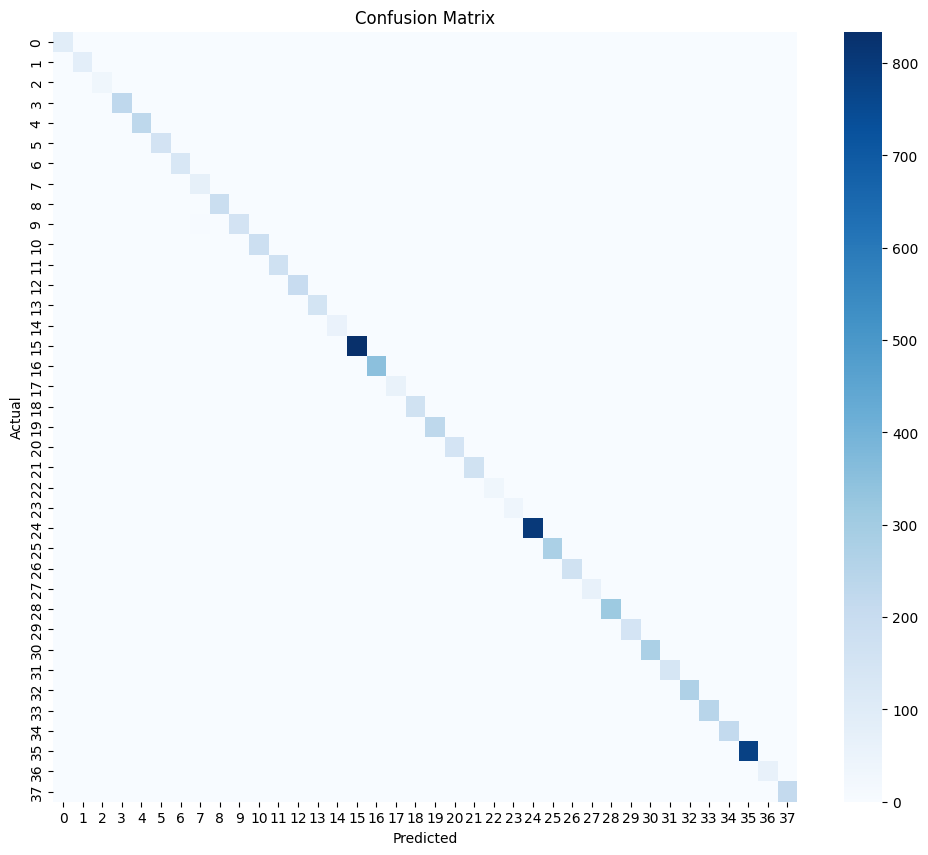

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Axes: >

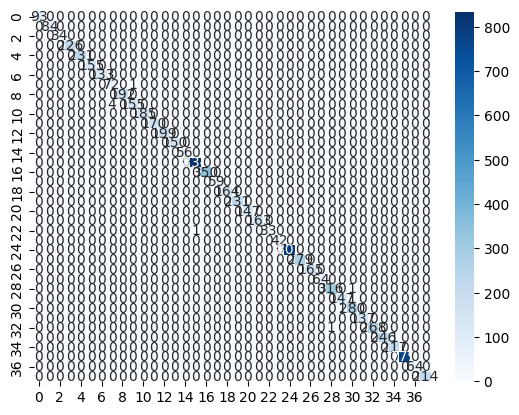

In [13]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

In [14]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        93
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        34
           3       1.00      1.00      1.00       226
           4       1.00      1.00      1.00       231
           5       1.00      1.00      1.00       155
           6       1.00      1.00      1.00       133
           7       0.95      0.99      0.97        73
           8       1.00      1.00      1.00       192
           9       0.99      0.97      0.98       159
          10       1.00      1.00      1.00       185
          11       1.00      1.00      1.00       170
          12       1.00      1.00      1.00       199
          13       1.00      1.00      1.00       150
          14       1.00      1.00      1.00        56
          15       1.00      1.00      1.00       834
          16       1.00      1.00      1.00       350
          17       1.00    

In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params = count_parameters(resnet_model)

print("Trainable Parameters:", params)
print("Parameters (Millions):", params/1e6)

Trainable Parameters: 23585894
Parameters (Millions): 23.585894


In [16]:
import time

def measure_inference_time(model, loader, device):

    model.eval()
    start = time.time()

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)

    end = time.time()

    total_images = len(loader.dataset)
    total_time = end - start
    time_per_image = total_time / total_images

    print("Total inference time:", total_time)
    print("Time per image:", time_per_image)

In [17]:
measure_inference_time(resnet_model, test_loader, device)

Total inference time: 28.798611402511597
Time per image: 0.0035348731315222284


In [18]:
# ===============================
# VISION TRANSFORMER EVALUATION
# ===============================

import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import ViTForImageClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# -------------------------------------------------
# 1. DEVICE SETUP (GPU if available)
# -------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# -------------------------------------------------
# 2. LOAD VISION TRANSFORMER MODEL
# -------------------------------------------------
# Using pretrained ViT Base and adapting final layer
# for PlantVillage classification

num_classes = 38   # PlantVillage dataset classes

vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes
)

vit_model = vit_model.to(device)

print("ViT architecture loaded")


# -------------------------------------------------
# 3. LOAD TRAINED WEIGHTS
# -------------------------------------------------
# Replace path with your saved model

model_path = "/kaggle/input/models/vanshikagargai/vit-trained-model/pytorch/default/1/vit_plant_disease.pth"

vit_model.load_state_dict(torch.load(model_path))

vit_model.eval()

print("Trained weights loaded successfully")


# -------------------------------------------------
# 4. TEST SET EVALUATION
# -------------------------------------------------

def evaluate_model(model, test_loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).logits
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    print("\n==============================")
    print("TEST PERFORMANCE")
    print("==============================")
    print("Test Accuracy :", acc)
    print("Test F1 Score :", f1)

    return all_labels, all_preds


labels, preds = evaluate_model(vit_model, test_loader)


# -------------------------------------------------
# 5. CONFUSION MATRIX
# -------------------------------------------------

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")

plt.title("Vision Transformer Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


# -------------------------------------------------
# 6. PARAMETER COUNT
# -------------------------------------------------

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params = count_parameters(vit_model)

print("\n==============================")
print("MODEL COMPLEXITY")
print("==============================")
print("Trainable Parameters :", params)
print("Parameters (Millions):", params / 1e6)


# -------------------------------------------------
# 7. INFERENCE SPEED BENCHMARK
# -------------------------------------------------

def measure_inference_time(model, loader):

    model.eval()

    start = time.time()

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)

    end = time.time()

    total_images = len(loader.dataset)
    total_time = end - start
    time_per_image = total_time / total_images

    print("\n==============================")
    print("INFERENCE SPEED")
    print("==============================")
    print("Total inference time :", total_time, "seconds")
    print("Time per image :", time_per_image, "seconds")


measure_inference_time(vit_model, test_loader)


# -------------------------------------------------
# 8. SUMMARY OUTPUT
# -------------------------------------------------

print("\n==============================")
print("EVALUATION COMPLETE")
print("==============================")
print("Model : ViT Base Patch16")
print("Dataset : PlantVillage")

Using device: cuda


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([38])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([38, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


RuntimeError: You set `ignore_mismatched_sizes` to `False`, thus raising an error. For details look at the above report!